In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import helpers
import time

from radioimaging.visibility import residual, weights, bda, vissim
from radioimaging.util import util
from radioimaging.images import images

from astropy.coordinates import SkyCoord
import astropy.units as u

from rascil.processing_components import plot_uvcoverage

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]

/usr/lib/python3.10/abc.py:106: FutureWarning: xarray subclass Visibility should explicitly define __slots__
  cls = super().__new__(mcls, name, bases, namespace, **kwargs)


In [2]:
gt_name = "SGRC"
config_name = "LOW"

phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-15.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-0.1,0.1)

bandwidth = 1e4
lowest_freq = 1e9
frequencies = range(int(lowest_freq), int(lowest_freq + bandwidth*1), int(bandwidth))
bandwidths = [bandwidth] * len(frequencies)
int_time = 5

vt = vissim.generate_visibilities(phasecentre,ha_interval,tel=config_name, integration_time=int_time, frequencies=numpy.array(frequencies).astype(float), channel_bandwidths=numpy.array(bandwidths))

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.
/home/sunwang/rascil-main-orig/rascil-main/rascil/processing_components/simulation/simulation_helpers.py:246: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_file)
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


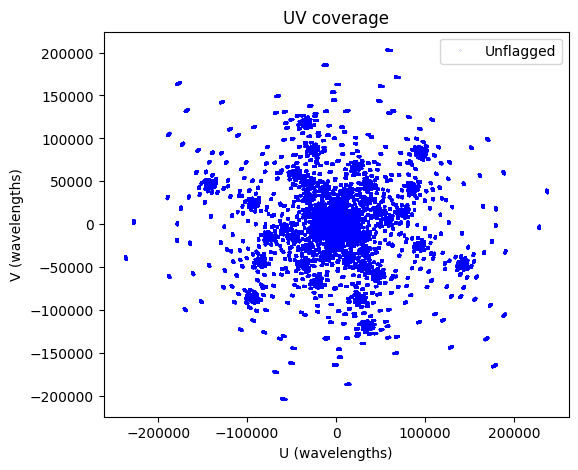

In [3]:
if vt.vis.size < 1e8:
    matplotlib.rcParams['figure.figsize'] = [6, 5]
    plot_uvcoverage([vt], plot_file="../figures/nonaveraged_SKAMID.png")


In [4]:
num_pix = util.fromfits('../data7/' + gt_name + '_full_gt.fits').shape[0]
vt, cell_size, im = residual.visibilities_from_image(vt,'../data7/' + gt_name + '_full_gt.fits',return_cellsize=True,return_image=True,scale_factor=1.8)
dirty, psf = residual.dirty_psf_from_visibilities(vt,cell_size,npix=num_pix,weighting="uniform", override_cellsize=False)

field_size_rad = cell_size * num_pix
field_size_deg = field_size_rad * 180 / numpy.pi 

Model image plate scale (arcsec) is 3.903244e-01


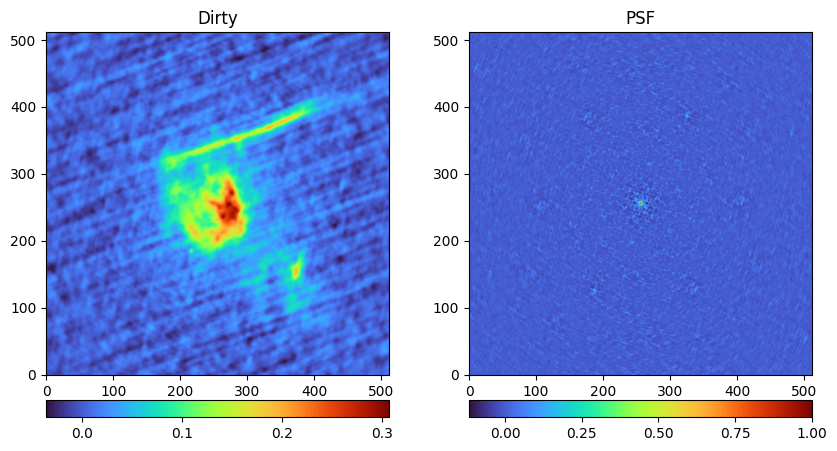

In [5]:
matplotlib.rcParams['figure.figsize'] = [10, 5]
util.plotNImages([dirty.pixels.data[0,0,:,:], psf.pixels.data[0, 0,:,:]], ["Dirty", "PSF"], cmap=cmap)
matplotlib.rcParams['figure.figsize'] = [5, 5]

[0,
 1.8402255008132336,
 8.74107112886286,
 26.22321338658858,
 63.02772340285325,
 235.08880772889057]

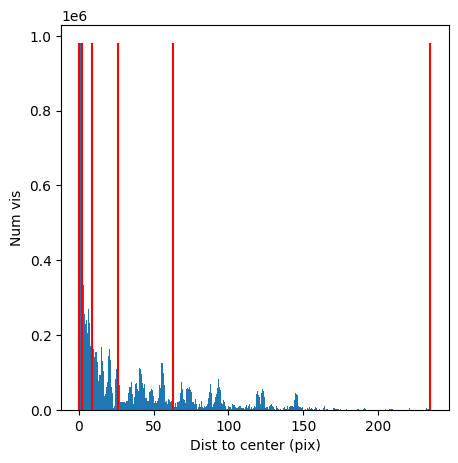

In [6]:
bda.generate_telescope_histogram(vt, show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=num_pix, pixel_size=cell_size,\
                                output_file="../figures/nonaveraged_SKAMID_histogram.png")

In [7]:

#field_size_deg = 3
start = time.time()
vaveraged = bda.bda(vt, 0.99, field_size_deg / 2, only_residual_decorr=False)
end = time.time()

print(end - start)

401.87222361564636


/home/sunwang/.local/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


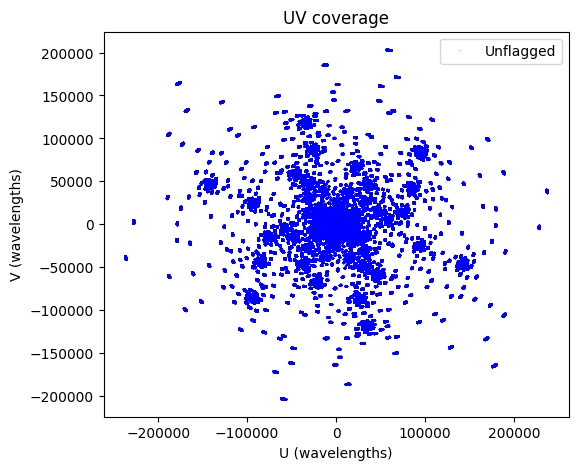

In [8]:
if vaveraged.vis.size < 1e8:
    matplotlib.rcParams['figure.figsize'] = [6, 5]
    plot_uvcoverage([vaveraged], plot_file="../figures/BDA_SKAMID_0.01.png")

In [10]:
dirty_averaged, psf_averaged = residual.dirty_psf_from_visibilities(vaveraged,cell_size,npix=num_pix,weighting="natural", override_cellsize=True)

Model image plate scale (arcsec) is 3.903244e-01


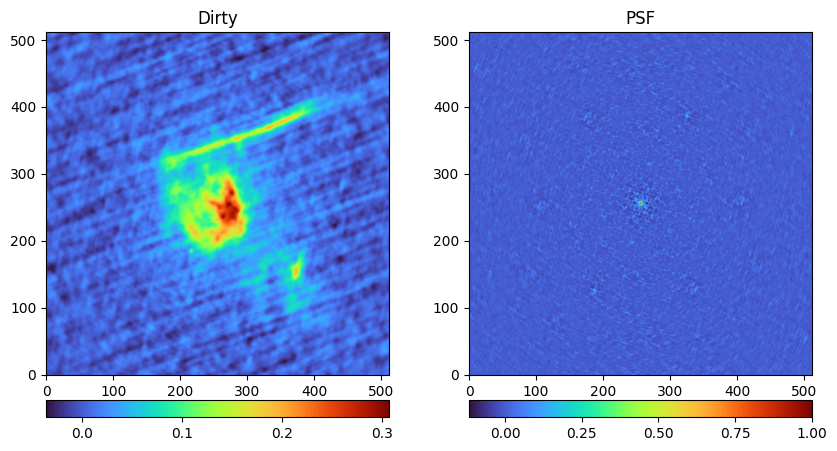

In [11]:
matplotlib.rcParams['figure.figsize'] = [10, 5]
util.plotNImages([dirty.pixels.data[0,0,:,:], psf.pixels.data[0, 0,:,:]], ["Dirty", "PSF"], cmap=cmap, output_file="../figures/bdaref.png")
matplotlib.rcParams['figure.figsize'] = [5, 5]

[0,
 33.124059014638206,
 51.52631402277054,
 71.76879453171611,
 96.15178241749145,
 235.08880772889057]

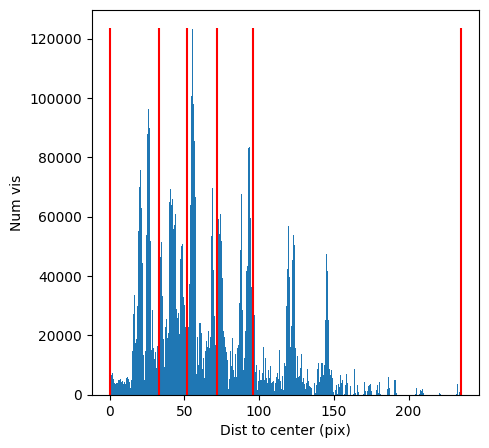

In [12]:
bda.generate_telescope_histogram(vaveraged, show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=cell_size,\
                                output_file="../figures/BDA_SKAMID_0.01_histogram.png")

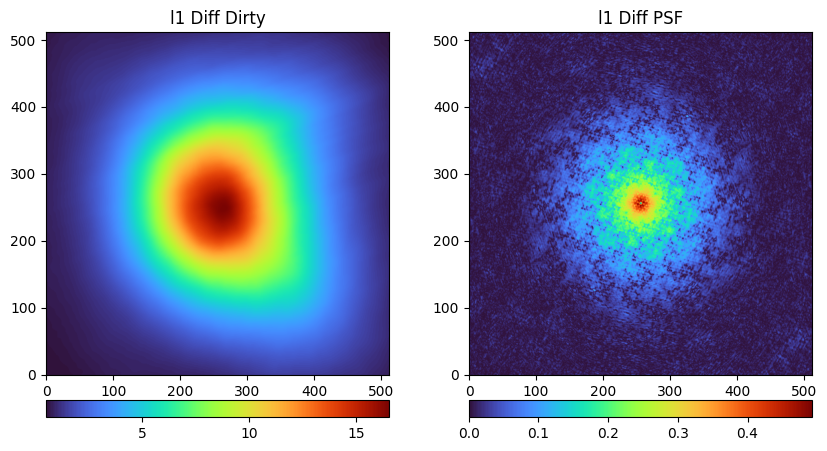

In [13]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

img_diff = numpy.abs(dirty.pixels.data[0,0,:,:] - dirty_averaged.pixels.data[0,0,:,:])
psf_diff = numpy.abs(psf.pixels.data[0,0,:,:] - psf_averaged.pixels.data[0,0,:,:])

util.plotNImages([img_diff, psf_diff], ["l1 Diff Dirty", "l1 Diff PSF"], cmap=cmap)

matplotlib.rcParams['figure.figsize'] = [5, 5]

In [14]:
util.tofits(img_diff, "../results/bda/fulldirtydif_0.1.fits")
util.tofits(psf_diff, "../results/bda/fullpsfdif_0.1.fits")

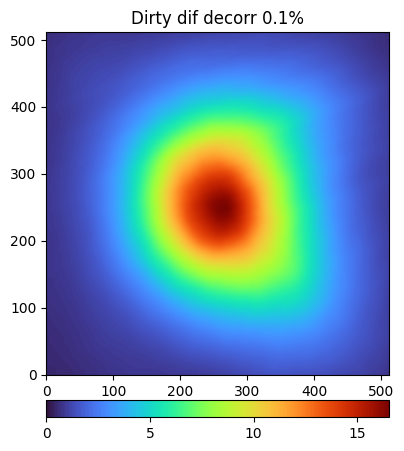

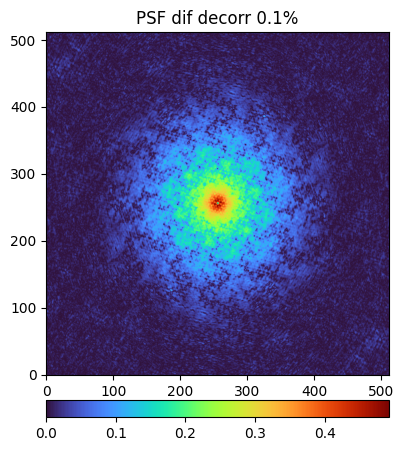

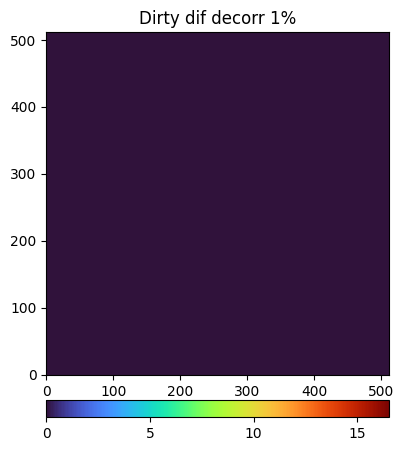

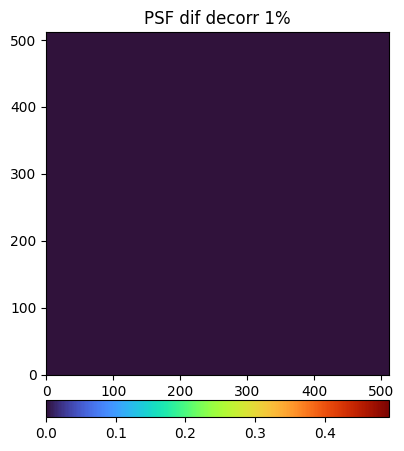

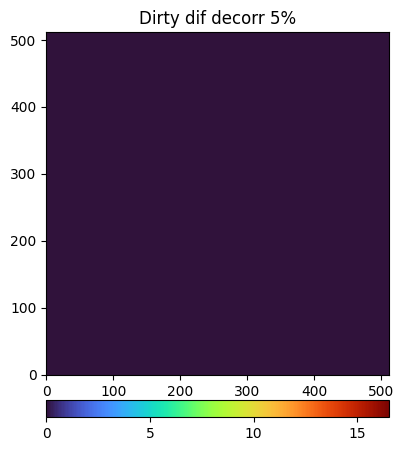

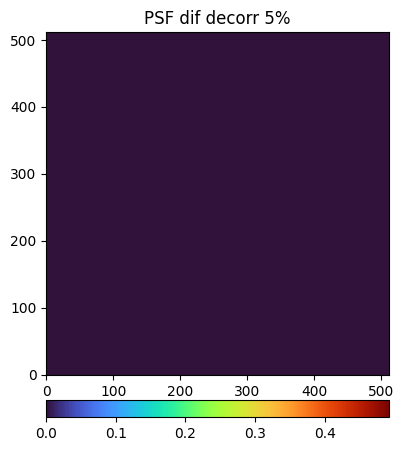

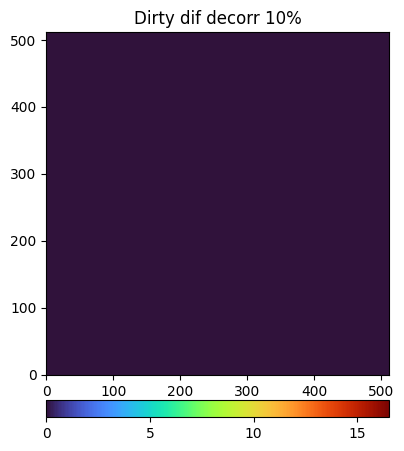

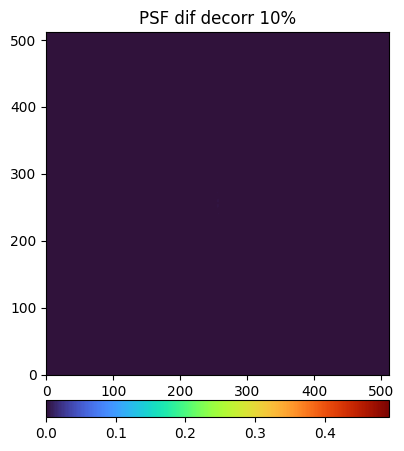

In [15]:
decorrs = [0.1, 1, 5, 10]

dirties = []
psfs = []

for decorr in decorrs:
    dirties.append(util.fromfits("../results/bda/fulldirtydif_" + str(decorr) + ".fits")) 
    psfs.append(util.fromfits("../results/bda/fullpsfdif_" + str(decorr) + ".fits")) 

for i, decorr in enumerate(decorrs):
    util.plotNImages([dirties[i]], ["Dirty dif decorr " + str(decorr) +"%"], cmap=cmap, same_scale=True, \
                        additional_scale_imgs = dirties, output_file = "../figures/fulldirtydif"+str(decorr)+".png")
    util.plotNImages([psfs[i]], ["PSF dif decorr " + str(decorr) +"%"], cmap=cmap, same_scale=True, \
                        additional_scale_imgs = psfs, output_file = "../figures/fullpsfdif"+str(decorr)+".png")

In [18]:
gt_name = "SGRC"
config_name = "MID"

phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-15.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-0.5,0.5)

bandwidth = 1e4
lowest_freq = 1e9
frequencies = range(int(lowest_freq), int(lowest_freq + bandwidth*1), int(bandwidth))
bandwidths = [bandwidth] * len(frequencies)
int_time = 5

vt = vissim.generate_visibilities(phasecentre,ha_interval,tel=config_name, integration_time=int_time, frequencies=numpy.array(frequencies).astype(float), channel_bandwidths=numpy.array(bandwidths))

num_pix = util.fromfits('../data7/' + gt_name + '_full_gt.fits').shape[0]
vt, cell_size, im = residual.visibilities_from_image(vt,'../data7/' + gt_name + '_full_gt.fits',return_cellsize=True,return_image=True,scale_factor=1.8)
dirty, psf = residual.dirty_psf_from_visibilities(vt,cell_size,npix=num_pix,weighting="natural", override_cellsize=False)

field_size_rad = cell_size * num_pix
field_size_deg = field_size_rad * 180 / numpy.pi 

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


Model image plate scale (arcsec) is 1.805883e-01


In [19]:
start = time.time()
bda.bda_and_export_to_ms2("../data8/bdatest.ms", vt, 0.99, field_size_deg / 2, only_residual_decorr=False)
end = time.time()

print(end - start)

93.17643761634827


In [20]:
print(cell_size)

8.755168963737264e-07
